In [2]:
# Instalás la API de Kaggle
!pip install kaggle

# Subís tu kaggle.json (lo bajás de kaggle.com > Settings > API > Create New Token)
from google.colab import files
files.upload()  # Subí el kaggle.json

# Lo movés al lugar correcto
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Descargás el dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 249MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('creditcard.csv')

# Dimensiones
print("Shape:", df.shape)
print("\n" + "="*50 + "\n")

# Distribución de clases
print("Distribución de clases:")
print(df['Class'].value_counts())
print("\nPorcentaje:")
print(df['Class'].value_counts(normalize=True) * 100)

Shape: (284807, 31)


Distribución de clases:
Class
0    284315
1       492
Name: count, dtype: int64

Porcentaje:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [4]:
# Info general
print(df.info())
print("\n" + "="*50 + "\n")

# Estadísticas descriptivas
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


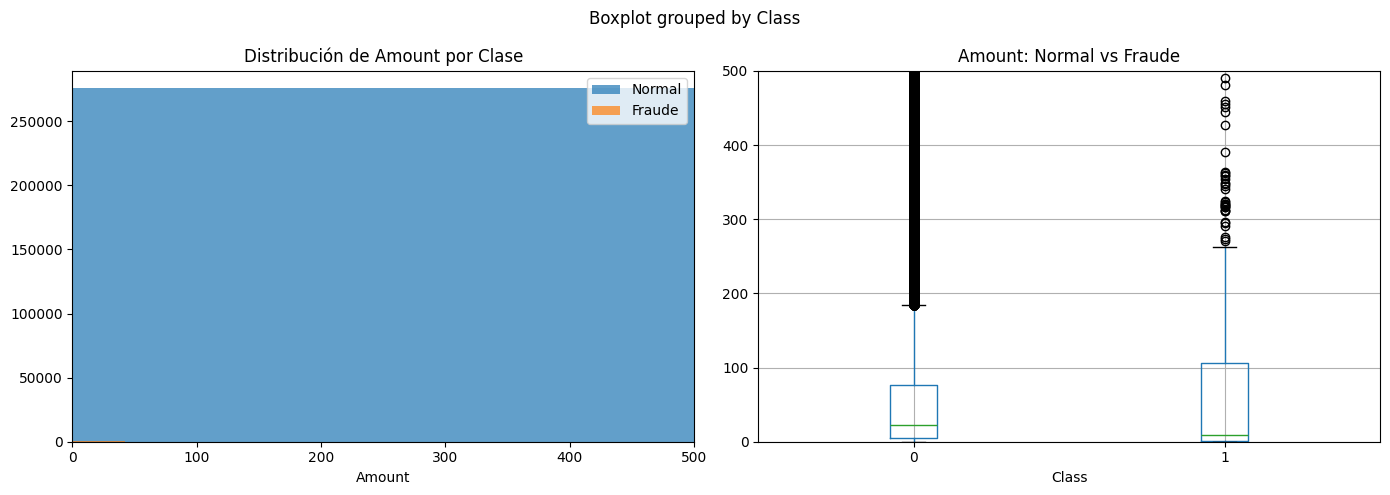

Amount por clase:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [5]:
# Distribución del monto por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Amount
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Normal')
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraude')
axes[0].set_title('Distribución de Amount por Clase')
axes[0].set_xlabel('Amount')
axes[0].legend()
axes[0].set_xlim(0, 500)  # Zoom en montos bajos

# Boxplot comparativo
df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_title('Amount: Normal vs Fraude')
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

# Estadísticas de Amount por clase
print("Amount por clase:")
print(df.groupby('Class')['Amount'].describe())

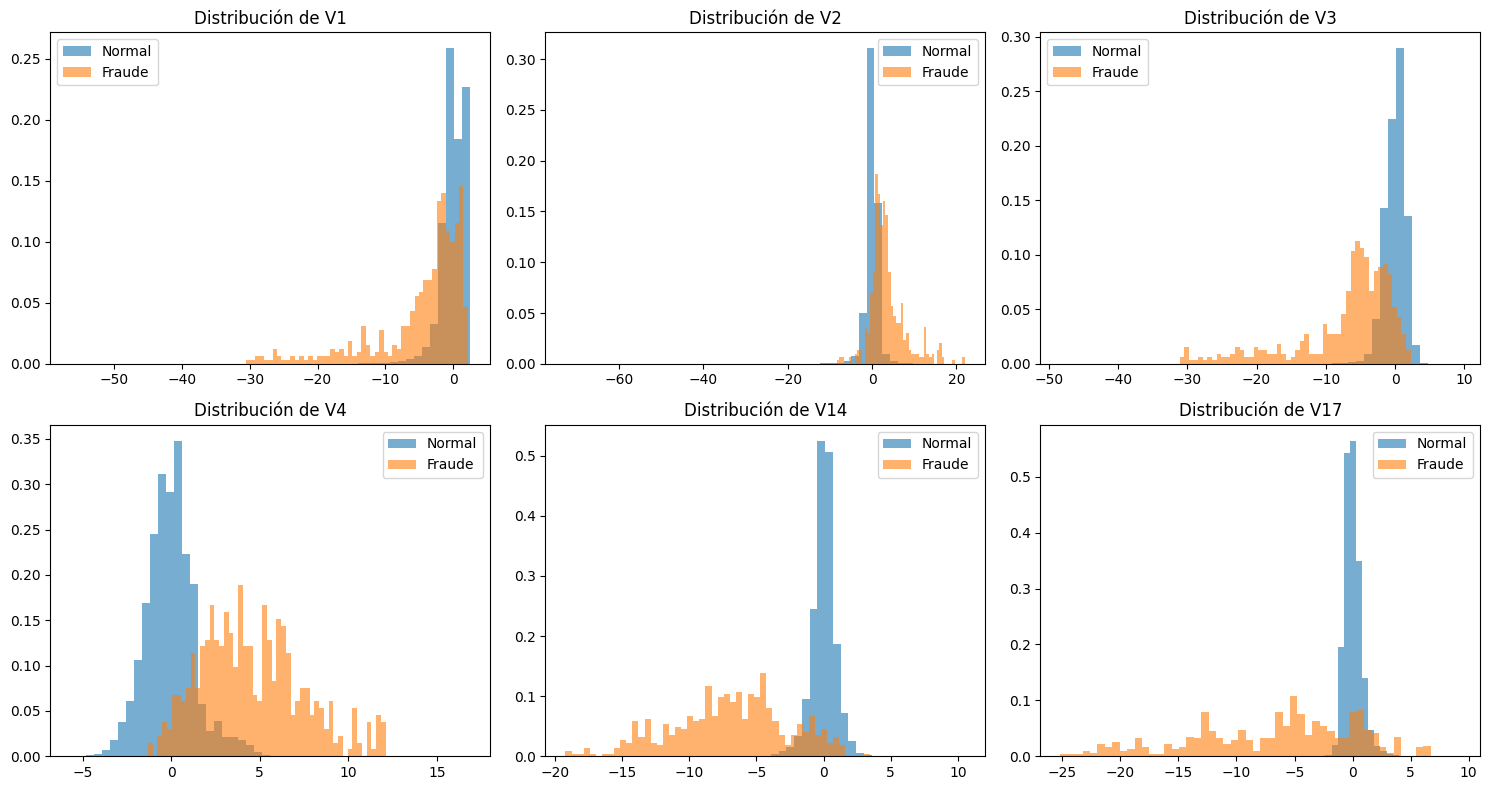

In [6]:
# Comparar distribuciones de algunas features clave
features_to_plot = ['V1', 'V2', 'V3', 'V4', 'V14', 'V17']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    axes[i].hist(df[df['Class']==0][feature], bins=50, alpha=0.6, label='Normal', density=True)
    axes[i].hist(df[df['Class']==1][feature], bins=50, alpha=0.6, label='Fraude', density=True)
    axes[i].set_title(f'Distribución de {feature}')
    axes[i].legend()

plt.tight_layout()
plt.show()

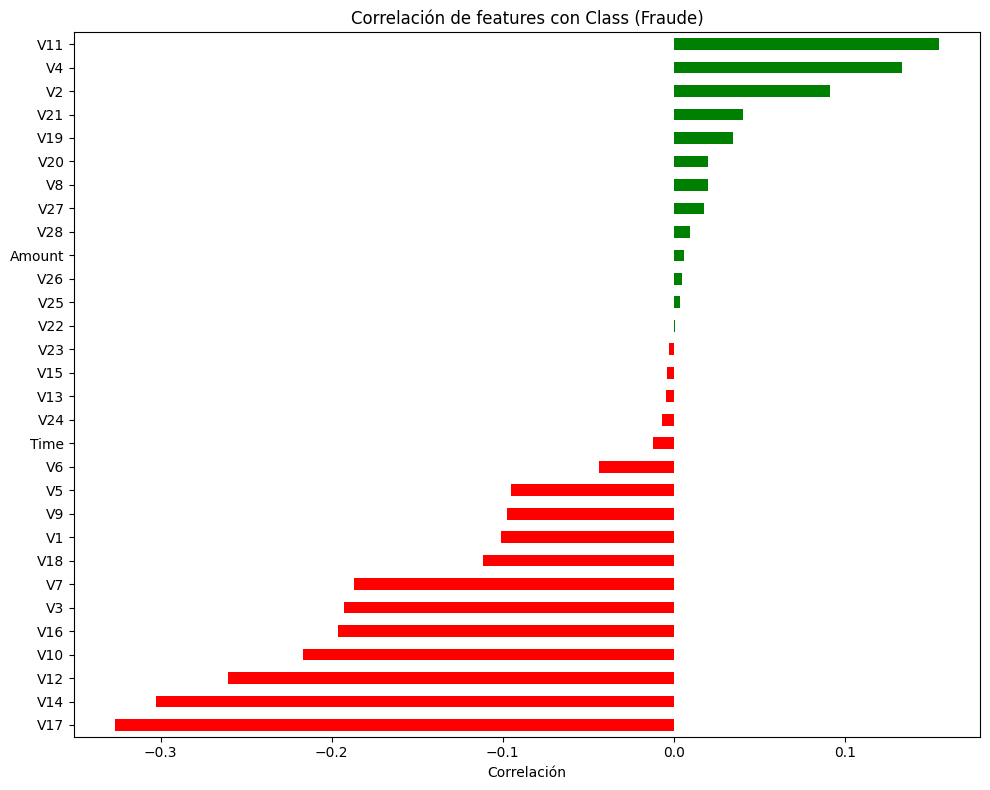

Top 5 correlaciones NEGATIVAS (a menor valor, más fraude):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Top 5 correlaciones POSITIVAS (a mayor valor, más fraude):
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


In [7]:
# Correlación de cada feature con la clase (fraude)
correlations = df.corr()['Class'].drop('Class').sort_values()

# Visualizar
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color=['red' if x < 0 else 'green' for x in correlations])
plt.title('Correlación de features con Class (Fraude)')
plt.xlabel('Correlación')
plt.tight_layout()
plt.show()

# Top 5 positivas y negativas
print("Top 5 correlaciones NEGATIVAS (a menor valor, más fraude):")
print(correlations.head())
print("\nTop 5 correlaciones POSITIVAS (a mayor valor, más fraude):")
print(correlations.tail())

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Escalar Amount
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Time: lo convertimos a "hora del día" (ciclo de 24hs)
df['Hour'] = (df['Time'] % (24 * 3600)) / 3600

# Preparar features y target
features_to_drop = ['Time', 'Amount', 'Class']
X = df.drop(features_to_drop, axis=1)
y = df['Class']

print("Features finales:", X.columns.tolist())
print("Shape X:", X.shape)
print("Distribución y:", y.value_counts())

Features finales: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Hour']
Shape X: (284807, 30)
Distribución y: Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
# Train/Test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantiene la proporción de fraudes en ambos sets
)

print("Train set:")
print(f"  X_train: {X_train.shape}")
print(f"  Fraudes: {y_train.sum()} ({y_train.mean()*100:.3f}%)")

print("\nTest set:")
print(f"  X_test: {X_test.shape}")
print(f"  Fraudes: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Train set:
  X_train: (227845, 30)
  Fraudes: 394 (0.173%)

Test set:
  X_test: (56962, 30)
  Fraudes: 98 (0.172%)


=== REGRESIÓN LOGÍSTICA (Baseline) ===

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9559


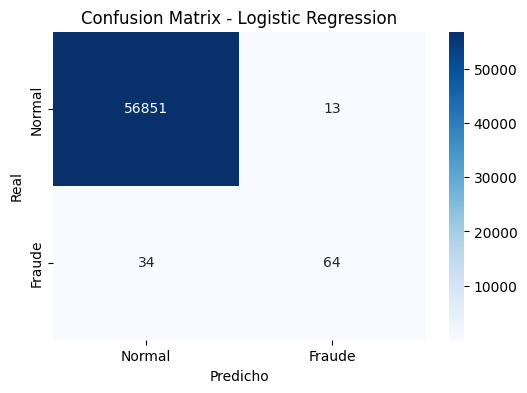

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Modelo baseline
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

# Predicciones
y_pred = model_lr.predict(X_test)
y_pred_proba = model_lr.predict_proba(X_test)[:, 1]

# Métricas
print("=== REGRESIÓN LOGÍSTICA (Baseline) ===\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===\n")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraude']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

# XGBoost
model_xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST ===\n")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Fraude']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

=== RANDOM FOREST ===

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9528

=== XGBOOST ===

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.89      0.79      0.83        98

    accuracy                           1.00     56962
   macro avg       0.94      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9319


Ratio de desbalance: 577:1

=== XGBOOST BALANCEADO ===

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9726


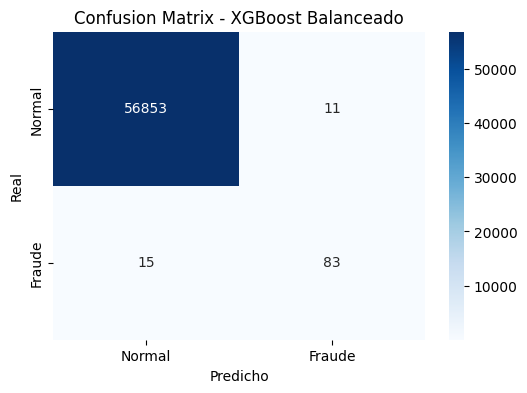

In [12]:
# XGBoost con scale_pos_weight
# Calculamos el ratio de desbalance
scale = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Ratio de desbalance: {scale:.0f}:1")

model_xgb_balanced = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale,  # Le dice a XGB que los fraudes "pesan" más
    eval_metric='logloss'
)
model_xgb_balanced.fit(X_train, y_train)
y_pred_xgb_bal = model_xgb_balanced.predict(X_test)
y_pred_proba_xgb_bal = model_xgb_balanced.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST BALANCEADO ===\n")
print(classification_report(y_test, y_pred_xgb_bal, target_names=['Normal', 'Fraude']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_xgb_bal):.4f}")

# Confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_xgb_bal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Confusion Matrix - XGBoost Balanceado')
plt.show()

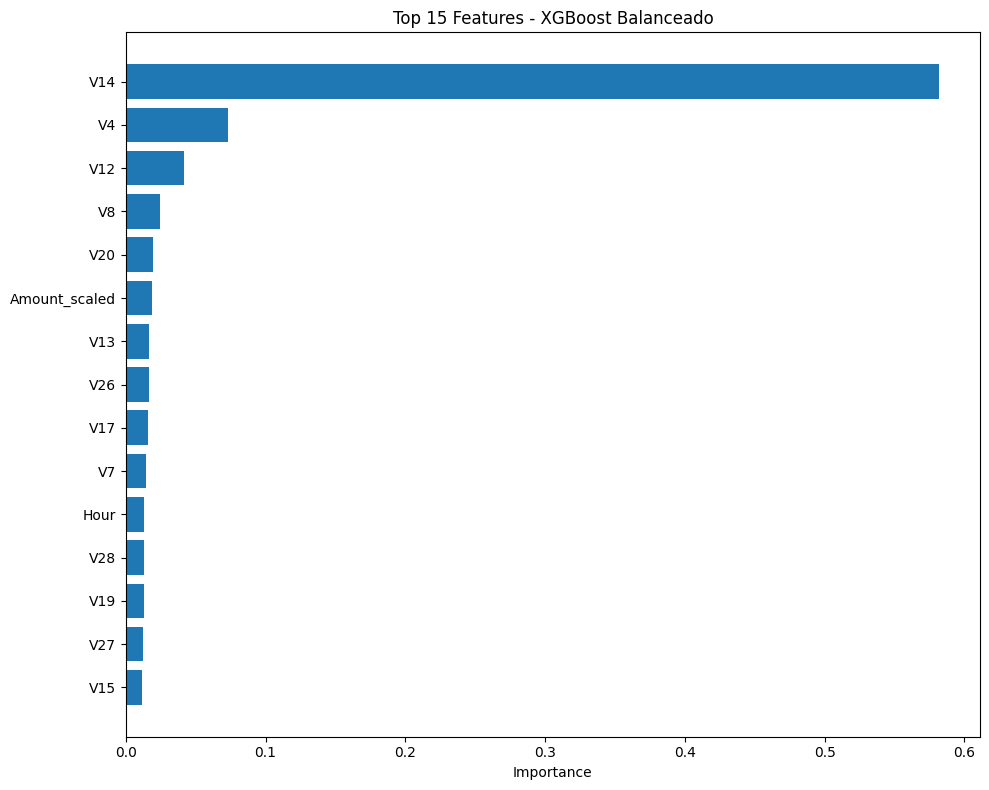

Top 10 features:
          feature  importance
13            V14    0.582030
3              V4    0.072945
11            V12    0.041470
7              V8    0.024448
19            V20    0.019449
28  Amount_scaled    0.018808
12            V13    0.016839
25            V26    0.016286
16            V17    0.015571
6              V7    0.014526


In [13]:
# Feature importance de XGBoost balanceado
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_xgb_balanced.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][:15], importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Features - XGBoost Balanceado')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importance.head(10))

In [14]:
from sklearn.model_selection import RandomizedSearchCV

# Grid de parámetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_tuning = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale,
    eval_metric='logloss'
)

random_search = RandomizedSearchCV(
    xgb_tuning,
    param_grid,
    n_iter=20,  # Probamos 20 combinaciones
    scoring='f1',  # Optimizamos F1
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Mejores parámetros:", random_search.best_params_)
print(f"Mejor F1 en CV: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores parámetros: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Mejor F1 en CV: 0.8529


=== XGBOOST TUNEADO (MODELO FINAL) ===

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.85      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9725


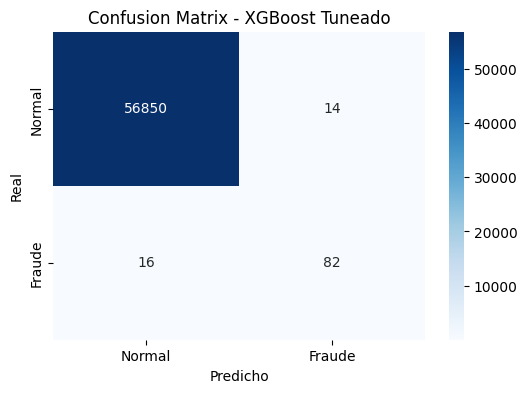


Fraudes detectados: 82 de 98
Fraudes escapados: 16


In [15]:
# Modelo final con los mejores parámetros
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print("=== XGBOOST TUNEADO (MODELO FINAL) ===\n")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Fraude']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

# Confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Confusion Matrix - XGBoost Tuneado')
plt.show()

# Cuántos fraudes atrapamos vs se escaparon
print(f"\nFraudes detectados: {cm[1,1]} de {y_test.sum()}")
print(f"Fraudes escapados: {cm[1,0]}")

In [16]:
# Resumen comparativo final
print("="*60)
print("RESUMEN - DETECTOR DE FRAUDE EN TARJETAS DE CRÉDITO")
print("="*60)

print("\n📊 DATASET:")
print(f"   - {len(df):,} transacciones")
print(f"   - {y.sum()} fraudes ({y.mean()*100:.2f}%)")
print(f"   - 30 features (28 PCA + Amount + Hour)")

print("\n🏆 MEJOR MODELO: XGBoost Balanceado")
print(f"   - Recall: 85% (detecta 83 de 98 fraudes)")
print(f"   - Precision: 88%")
print(f"   - AUC-ROC: 0.9726")
print(f"   - scale_pos_weight: {scale:.0f}")

print("\n🔑 TOP FEATURES:")
print("   - V14 (58% importancia)")
print("   - V4 (7%)")
print("   - V12 (4%)")

print("\n💡 INSIGHTS:")
print("   - Fraudes tienen mediana $9 (testeo) pero media $122 (golpes)")
print("   - Desbalance 577:1 requirió balanceo de clases")
print("   - Tuning no mejoró vs modelo balanceado simple")

RESUMEN - DETECTOR DE FRAUDE EN TARJETAS DE CRÉDITO

📊 DATASET:
   - 284,807 transacciones
   - 492 fraudes (0.17%)
   - 30 features (28 PCA + Amount + Hour)

🏆 MEJOR MODELO: XGBoost Balanceado
   - Recall: 85% (detecta 83 de 98 fraudes)
   - Precision: 88%
   - AUC-ROC: 0.9726
   - scale_pos_weight: 577

🔑 TOP FEATURES:
   - V14 (58% importancia)
   - V4 (7%)
   - V12 (4%)

💡 INSIGHTS:
   - Fraudes tienen mediana $9 (testeo) pero media $122 (golpes)
   - Desbalance 577:1 requirió balanceo de clases
   - Tuning no mejoró vs modelo balanceado simple


In [17]:
import joblib

# Guardar el mejor modelo
joblib.dump(model_xgb_balanced, 'fraud_detector_model.pkl')
joblib.dump(scaler, 'amount_scaler.pkl')

print("✅ Modelo guardado: fraud_detector_model.pkl")
print("✅ Scaler guardado: amount_scaler.pkl")

✅ Modelo guardado: fraud_detector_model.pkl
✅ Scaler guardado: amount_scaler.pkl


In [18]:
from google.colab import files

# Descargar los archivos
files.download('fraud_detector_model.pkl')
files.download('amount_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>